# Waiter Tips Prediction

In [2]:
!pip install plotly

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

data = pd.read_csv("tips.csv")
print(data.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [4]:
!pip install statsmodels

In [5]:
!pip install -U kaleido


In [6]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

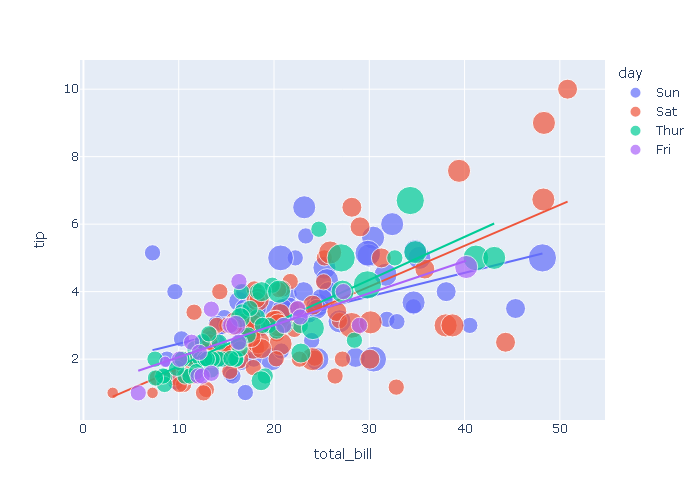

In [7]:
figure = px.scatter(data_frame = data, x="total_bill",
                    y="tip", size="size", color= "day", trendline="ols")
figure.show()
figure.show("png")

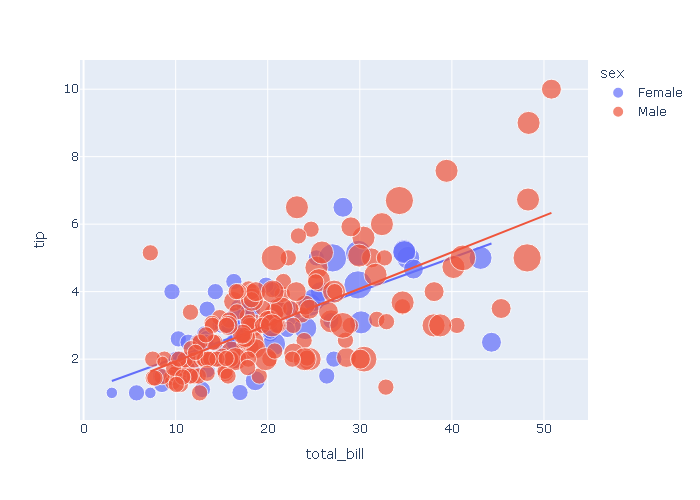

In [8]:
figure = px.scatter(data_frame = data, x="total_bill",
                    y="tip", size="size", color= "sex", trendline="ols")
figure.show()
figure.show("png")

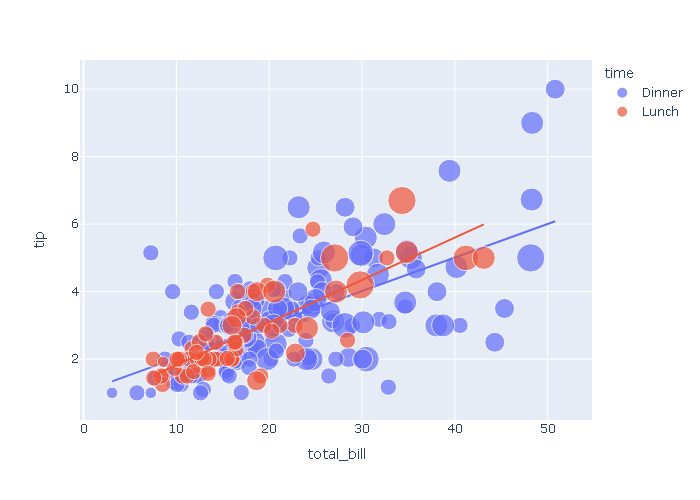

In [9]:
figure = px.scatter(data_frame = data, x="total_bill",
                    y="tip", size="size", color= "time", trendline="ols")
figure.show()
figure.show("png")

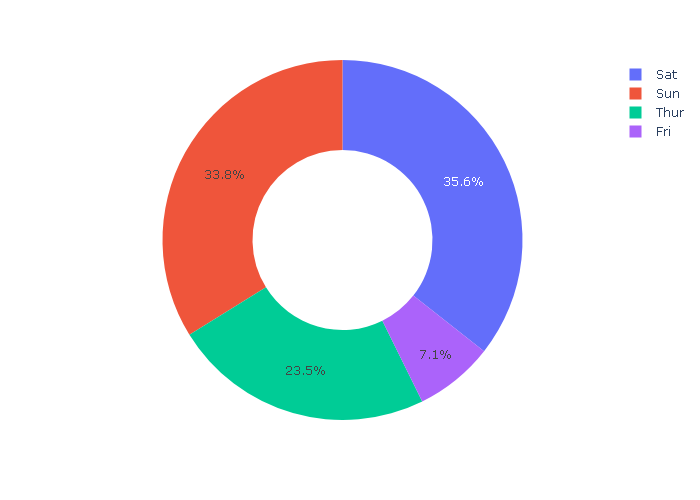

In [10]:
figure = px.pie(data, 
             values='tip', 
             names='day',hole = 0.5)
figure.show()
figure.show("png")

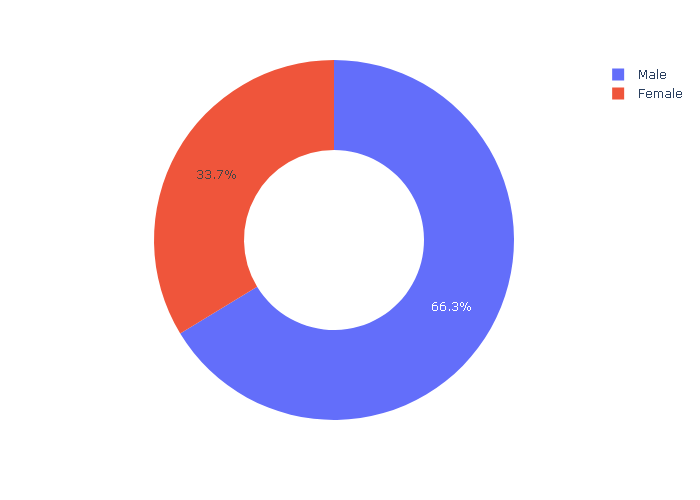

In [11]:
figure = px.pie(data, 
             values='tip', 
             names='sex',hole = 0.5)
figure.show()
figure.show("png")

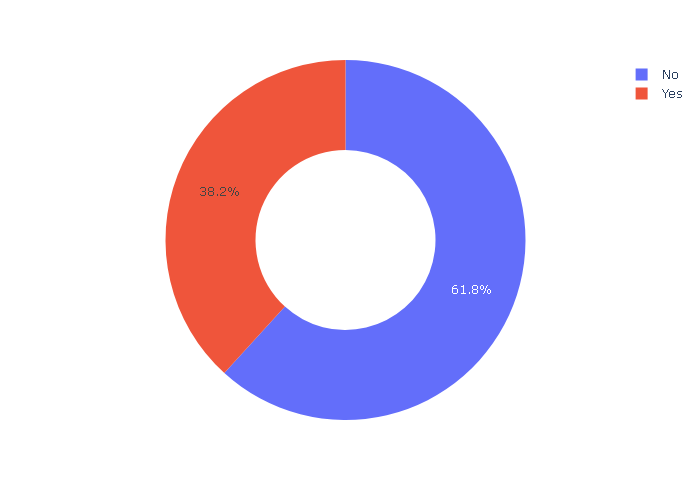

In [12]:
figure = px.pie(data, 
             values='tip', 
             names='smoker',hole = 0.5)
figure.show()
figure.show("png")

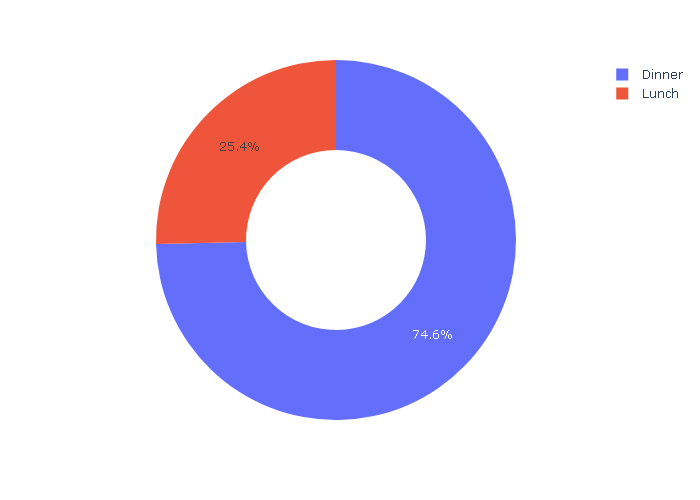

In [13]:
figure = px.pie(data, 
             values='tip', 
             names='time',hole = 0.5)
figure.show()
figure.show("png")

## Waiter Tips Prediction Model

In [14]:
data["sex"] = data["sex"].map({"Female": 0, "Male": 1})
data["smoker"] = data["smoker"].map({"No": 0, "Yes": 1})
data["day"] = data["day"].map({"Thur": 0, "Fri": 1, "Sat": 2, "Sun": 3})
data["time"] = data["time"].map({"Lunch": 0, "Dinner": 1})
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,3,1,2
1,10.34,1.66,1,0,3,1,3
2,21.01,3.50,1,0,3,1,3
3,23.68,3.31,1,0,3,1,2
4,24.59,3.61,0,0,3,1,4


In [15]:
!pip install scikit-learn

In [16]:
!conda clean --all -y

Will remove 6 (35.4 MB) tarball(s).
Will remove 1 index cache(s).
Will remove 2 (784 KB) package(s).
There are no tempfile(s) to remove.
There are no logfile(s) to remove.


In [4]:
!conda install -n financials_env scikit-learn -y

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\isha\miniconda3\envs\financials_env

  added / updated specs:
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.3.19  |       haa95532_0         126 KB
    certifi-2026.01.04         |  py310haa95532_0         148 KB
    joblib-1.5.3               |  py310haa95532_0         408 KB
    scikit-learn-1.6.1         |  py310h585ebfc_0         8.4 MB
    scipy-1.15.3               |  py310h180bac5_0        26.3 MB
    threadpoolctl-3.5.0        |  py310h4442805_1          42 KB
    ------------------------------------------------------------
                                           Total:        35.4 MB

The following NEW packages will be INSTALLED:

  icc_rt             pkgs/main



==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [ ]:
! conda update -n base -c defaults conda

In [17]:
x = np.array(data[["total_bill", "sex", "smoker", "day", 
                   "time", "size"]])
y = np.array(data["tip"])

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, 
                                                test_size=0.2, 
                                                random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(xtrain, ytrain)

LinearRegression()

In [19]:
# features = [[total_bill, "sex", "smoker", "day", "time", "size"]]
features = np.array([[24.50, 1, 0, 0, 1, 4]])
model.predict(features)

array([3.73742609])